In [18]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

MI_NAVY = "#004B8D"
MI_GOLD = "#D1AB65"
MI_LIGHT = "#3D8FD6"
MI_RED =   "#C0392B"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 11

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(42)

In [19]:
df_model = pd.read_csv("IPL_2008_-_2026-Lasso.csv")
print("Shape: ", df_model.shape)
df_model.head()

Shape:  (1218, 31)


,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,team2_runs,team2_wickets,winner,result_type,win_by_runs,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players,team1_wickets_remaining,team2_run_rate,total_wickets_fell,run_margin_dup,wicket_margin_dup,team2_runs_x2
0,18-04-2008,2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,82,10,222,3,Kolkata Knight Riders,complete,140,0,BB McCullum,J Srinath,Asad Rauf,RE Koertzen,AM Saheba,VN Kulkarni,20,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",0,11.10,13,140.0,0.0,444.0
1,19-04-2008,2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,207,4,240,5,Chennai Super Kings,complete,33,0,MEK Hussey,S Venkataraghavan,MR Benson,SL Shastri,RB Tiffin,MSS Ranawat,20,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",6,12.00,9,33.0,0.0,480.0
2,19-04-2008,2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,132,1,129,8,Delhi Daredevils,complete,0,9,MF Maharoof,GR Viswanath,Aleem Dar,GA Pratapkumar,IL Howell,Unknown,20,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",9,6.45,9,0.0,9.0,258.0
3,20-04-2008,2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,112,5,110,10,Kolkata Knight Riders,complete,0,5,DJ Hussey,FM Engineer,BF Bowden,K Hariharan,Asad Rauf,F Gomes,20,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",5,5.50,15,0.0,5.0,220.0
4,20-04-2008,2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,165,7,166,5,Royal Challengers Bangalore,complete,0,5,MV Boucher,J Srinath,SJ Davis,DJ Harper,AV Jayaprakash,SN Bandekar,20,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",3,8.30,12,0.0,5.0,332.0


In [20]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     1218 non-null   str    
 1   season                   1218 non-null   str    
 2   city                     1218 non-null   str    
 3   venue                    1218 non-null   str    
 4   team1                    1218 non-null   str    
 5   team2                    1218 non-null   str    
 6   toss_winner              1218 non-null   str    
 7   toss_decision            1218 non-null   str    
 8   team1_runs               1218 non-null   int64  
 9   team1_wickets            1218 non-null   int64  
 10  team2_runs               1218 non-null   int64  
 11  team2_wickets            1218 non-null   int64  
 12  winner                   1218 non-null   str    
 13  result_type              1218 non-null   str    
 14  win_by_runs              1218 non-n

In [21]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
team1_runs,1218.0,166.224138,34.885513,58.0,144.0,165.0,188.75,287.00
team1_wickets,1218.0,5.954844,2.301533,0.0,4.0,6.0,8.00,10.00
team2_runs,1218.0,158.112479,32.574213,44.0,138.0,160.0,179.00,265.00
team2_wickets,1218.0,5.885878,2.615160,0.0,4.0,6.0,8.00,10.00
win_by_runs,1218.0,14.218391,24.020840,0.0,0.0,0.0,20.00,146.00
win_by_wickets,1218.0,3.344007,3.359195,0.0,0.0,3.0,6.00,10.00
overs_limit,1218.0,20.000000,0.000000,20.0,20.0,20.0,20.00,20.00
team1_wickets_remaining,1218.0,4.045156,2.301533,0.0,2.0,4.0,6.00,10.00
team2_run_rate,1218.0,7.905624,1.628711,2.2,6.9,8.0,8.95,13.25
total_wickets_fell,1218.0,11.840722,3.053225,3.0,10.0,12.0,14.00,20.00


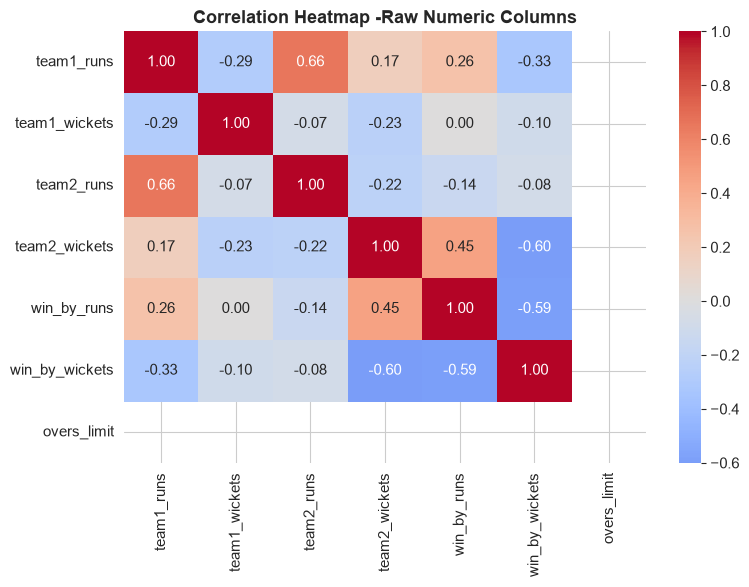

In [22]:
numeric_raw = ["team1_runs", "team1_wickets", "team2_runs","team2_wickets", "win_by_runs", "win_by_wickets","overs_limit"]

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df_model[numeric_raw].corr(), annot=True, fmt = ".2f", cmap="coolwarm", center=0, ax = ax)
ax.set_title("Correlation Heatmap -Raw Numeric Columns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
numeric_cols = ["team1_runs", "team1_wickets", "team2_runs","team2_wickets", "win_by_runs", "win_by_wickets","overs_limit",
               "team1_wickets_remaining", "team2_run_rate", "total_wickets_fell","run_margin_dup", "wicket_margin_dup","team2_runs_x2"]

categorical_cols = ["team1", "team2", "venue", "city", "toss_winner", "toss_decision", "season", "player_of_match"]

X = pd.get_dummies(df_model[numeric_cols + categorical_cols], columns=categorical_cols, drop_first=True)
y = df_model["team1_runs"]

print("Final Feature matrix shape : ", X.shape)
print("Number of rows (matches) : ", len(df_model))

Final Feature matrix shape :  (1218, 501)
Number of rows (matches) :  1218


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train shape : ", X_train_s.shape)
print("Test shape : ", X_test_s.shape)

Train shape :  (913, 501)
Test shape :  (305, 501)


In [25]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)

lr_train_r2 = r2_score(y_train, lr.predict(X_train_s))
lr_test_r2 = r2_score(y_test, lr.predict(X_test_s))
lr_gap = lr_train_r2 - lr_test_r2

print(f"Linear Regression --> Train R2 :{lr_train_r2 :.4f}")
print(f"Linear Regression --> Test R2 :{lr_test_r2:.4f}")
print(f"Train - Test gap (overfitting signal): {lr_gap:.4f}")

Linear Regression --> Train R2 :1.0000
Linear Regression --> Test R2 :1.0000
Train - Test gap (overfitting signal): 0.0000


In [34]:
lambdas = np.array([0.1,1,5,10,20,50,100,200,300,500,800,1000,1500,2000,3000])

train_scores, test_scores = [],[]
for a in lambdas: 
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_s,y_train)
    train_scores.append(r2_score(y_train, ridge.predict(X_train_s)))
    test_scores.append(r2_score(y_test, ridge.predict(X_test_s)))

results = pd.DataFrame({"lambdas":lambdas, "train_r2":train_scores, "test_r2":test_scores})
results["gap"] = results["train_r2"] - results["test_r2"]
results

,lambdas,train_r2,test_r2,gap
0,0.1,1.000000,1.000000,2.240608e-07
1,1.0,0.999992,0.999970,2.171792e-05
2,5.0,0.999814,0.999331,4.833543e-04
3,10.0,0.999331,0.997638,1.693541e-03
4,20.0,0.997780,0.992415,5.364793e-03
5,50.0,0.991119,0.971864,1.925461e-02
6,100.0,0.979305,0.940118,3.918716e-02
7,200.0,0.959764,0.897509,6.225534e-02
8,300.0,0.944457,0.870998,7.345825e-02
9,500.0,0.919998,0.837058,8.293989e-02


In [36]:
ridge_best = Ridge(alpha=500)
ridge_best.fit(X_train_s, y_train)

ridge_train_r2 = r2_score(y_train, ridge_best.predict(X_train_s))
ridge_test_r2 = r2_score(y_test, ridge_best.predict(X_test_s))
ridge_gap = ridge_train_r2- ridge_test_r2

print(f"Best lambda : {500}")
print(f"Ridge -> Train R2 : {ridge_train_r2:.4f}")
print(f"Ridge -> Test R2 : {ridge_test_r2:.4f}")
print(f"Train- Test gap : {ridge_gap:.4f}" )

Best lambda : 500
Ridge -> Train R2 : 0.9200
Ridge -> Test R2 : 0.8371
Train- Test gap : 0.0829
